# Figure 4 Boundary Enrichment Summary

This notebook reads the boundary-edge enrichment JSON files written by the non-SH3 Figure 4 system notebooks and plots the observed enrichment for each system, with permutation p-values from the matched-size random-edge null shown above each bar.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_SPECS =[
    {
        "slug": "kras_darpin_k27",
        "system_name": "KRAS DARPin K27",
        "plot_label": "KRAS\nDARPin K27"
    },
    {
        "slug": "kras_darpin_k55",
        "system_name": "KRAS DARPin K55",
        "plot_label": "KRAS\nDARPin K55"
    },
    {
        "slug": "kras_pik3cg",
        "system_name": "KRAS PIK3CG",
        "plot_label": "KRAS\nPIK3CG"
    },
    {
        "slug": "kras_raf1",
        "system_name": "KRAS RAF1",
        "plot_label": "KRAS\nRAF1"
    },
    {
        "slug": "kras_ralgds",
        "system_name": "KRAS RALGDS",
        "plot_label": "KRAS\nRALGDS"
    },
    {
        "slug": "kras_sos1",
        "system_name": "KRAS SOS1",
        "plot_label": "KRAS\nSOS1"
    },
    {
        "slug": "lycov",
        "system_name": "LYCoV",
        "plot_label": "LYCoV"
    }
]

def resolve_boundary_enrichment_output_dir():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "figure_notebooks_rev").is_dir():
            return candidate / "figure_notebooks_rev" / "boundary_enrichment_results"
    return cwd / "boundary_enrichment_results"

result_dir = resolve_boundary_enrichment_output_dir()
missing = [
    result_dir / f"{spec['slug']}_boundary_enrichment.json"
    for spec in RESULT_SPECS
    if not (result_dir / f"{spec['slug']}_boundary_enrichment.json").exists()
]
if missing:
    missing_list = "\n".join(str(path) for path in missing)
    raise FileNotFoundError(
        "Missing boundary enrichment result files. Re-run the corresponding Figure 4 notebooks first:\n"
        + missing_list
    )

records = []
for order, spec in enumerate(RESULT_SPECS):
    payload = json.loads((result_dir / f"{spec['slug']}_boundary_enrichment.json").read_text())
    records.append(
        {
            "sort_order": order,
            "system_slug": spec["slug"],
            "system_name": spec["system_name"],
            "plot_label": spec["plot_label"],
            "observed_enrichment": float(payload["observed"]["energy_share_enrichment"]),
            "null_p_enrichment": float(payload["null_same_size_random_edge_subsets"]["p_enrichment"]),
            "n_perm": int(payload["null_same_size_random_edge_subsets"]["n_perm"]),
        }
    )

summary_df = pd.DataFrame.from_records(records).sort_values("sort_order").reset_index(drop=True)
summary_df

,sort_order,system_slug,system_name,plot_label,observed_enrichment,null_p_enrichment,n_perm
0,0,kras_darpin_k27,KRAS DARPin K27,KRAS\nDARPin K27,1.363400,0.000999,1000
1,1,kras_darpin_k55,KRAS DARPin K55,KRAS\nDARPin K55,1.627838,0.000999,1000
2,2,kras_pik3cg,KRAS PIK3CG,KRAS\nPIK3CG,1.790590,0.000999,1000
3,3,kras_raf1,KRAS RAF1,KRAS\nRAF1,1.616207,0.000999,1000
4,4,kras_ralgds,KRAS RALGDS,KRAS\nRALGDS,2.005680,0.000999,1000
5,5,kras_sos1,KRAS SOS1,KRAS\nSOS1,1.838566,0.000999,1000
6,6,lycov,LYCoV,LYCoV,2.211828,0.004995,1000


Saved summary plot to /home/matthew-spence/graph-ruggedness-de/figure_notebooks_rev/boundary_enrichment_results/figure_4_boundary_enrichment_summary.png
Saved summary plot to /home/matthew-spence/graph-ruggedness-de/figure_notebooks_rev/boundary_enrichment_results/figure_4_boundary_enrichment_summary.pdf


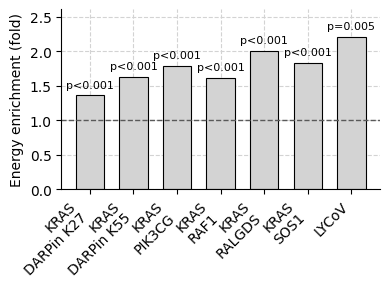

In [20]:
GREY = "#d3d3d3"

def format_p_value(p):
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"

x = np.arange(len(summary_df))
y_max = float(summary_df["observed_enrichment"].max()) * 1.18

fig, ax = plt.subplots(figsize=(4, 2.5))

ax.bar(
    x,
    summary_df["observed_enrichment"],
    width=0.65,
    color="#d3d3d3",
    edgecolor="black",
    linewidth=0.8,
)

for xi, y, p in zip(x, summary_df["observed_enrichment"], summary_df["null_p_enrichment"]):
    ax.text(
        xi,
        y + 0.03 * y_max,
        format_p_value(float(p)),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.axhline(1.0, color="0.35", linestyle="--", linewidth=1)
ax.set_xticks(x, summary_df["plot_label"])
ax.set_ylabel("Energy enrichment (fold)")
ax.set_xlabel("")
ax.set_title("")
ax.set_ylim(0, y_max)
ax.set_axisbelow(True)
ax.grid(True, linestyle="--", color=GREY)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


fig.tight_layout()
plt.xticks(rotation=45, ha="right")

png_path = result_dir / "figure_4_boundary_enrichment_summary.png"
pdf_path = result_dir / "figure_4_boundary_enrichment_summary.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

print(f"Saved summary plot to {png_path}")
print(f"Saved summary plot to {pdf_path}")
plt.show()